# Visualizing Data with Histograms

**Author:** Mitadru Deb  
**Date:** February 2026

This notebook focuses on using histograms to visualize distributions, relationships, and patterns in the developer survey data.

## Setting Up the Database

First, I'll download the SQLite database and set up the connection.

In [32]:
# Download the database file
import urllib.request

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite"
output_file = "survey-data.sqlite"

urllib.request.urlretrieve(url, output_file)

print("Download completed")

Download completed


## Importing Libraries

I'll import the necessary libraries for database operations and visualization.

In [33]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Connecting to the Database

Now I'll connect to the SQLite database.

In [34]:
# Connect to SQLite database
conn = sqlite3.connect('survey-data.sqlite')
print("✅ Database connection established")

✅ Database connection established


## Verifying the Database

Let me verify the database by running some basic queries.

In [35]:
# Count total rows
QUERY = "SELECT COUNT(*) as Total FROM main"
df = pd.read_sql_query(QUERY, conn)
print(f"Total records: {df['Total'][0]}")

Total records: 65437


In [36]:
# List all tables
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
tables = pd.read_sql_query(QUERY, conn)
print("Tables in database:")
print(tables)

Tables in database:
  Table_Name
0       main


In [37]:
# Group data by age
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print("Age distribution:")
print(df_age)

Age distribution:
                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Distribution of Data

### Histogram 1: Total Compensation

I'll create a histogram to show the distribution of total compensation.

In [38]:
# Query compensation data
QUERY = """
SELECT CompTotal 
FROM main 
WHERE CompTotal IS NOT NULL
"""
comp_data = pd.read_sql_query(QUERY, conn)

# Remove extreme outliers using IQR method for meaningful visualization
Q1 = comp_data['CompTotal'].quantile(0.25)
Q3 = comp_data['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
comp_data = comp_data[(comp_data['CompTotal'] >= Q1 - 1.5 * IQR) &
                      (comp_data['CompTotal'] <= Q3 + 1.5 * IQR)]

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(comp_data['CompTotal'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Total Compensation', fontsize=14, fontweight='bold')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total records: {len(comp_data)}")
print(f"Mean: {comp_data['CompTotal'].mean():,.2f}")
print(f"Median: {comp_data['CompTotal'].median():,.2f}")

### Histogram 2: Years of Professional Coding Experience

I'll visualize the distribution of coding experience.

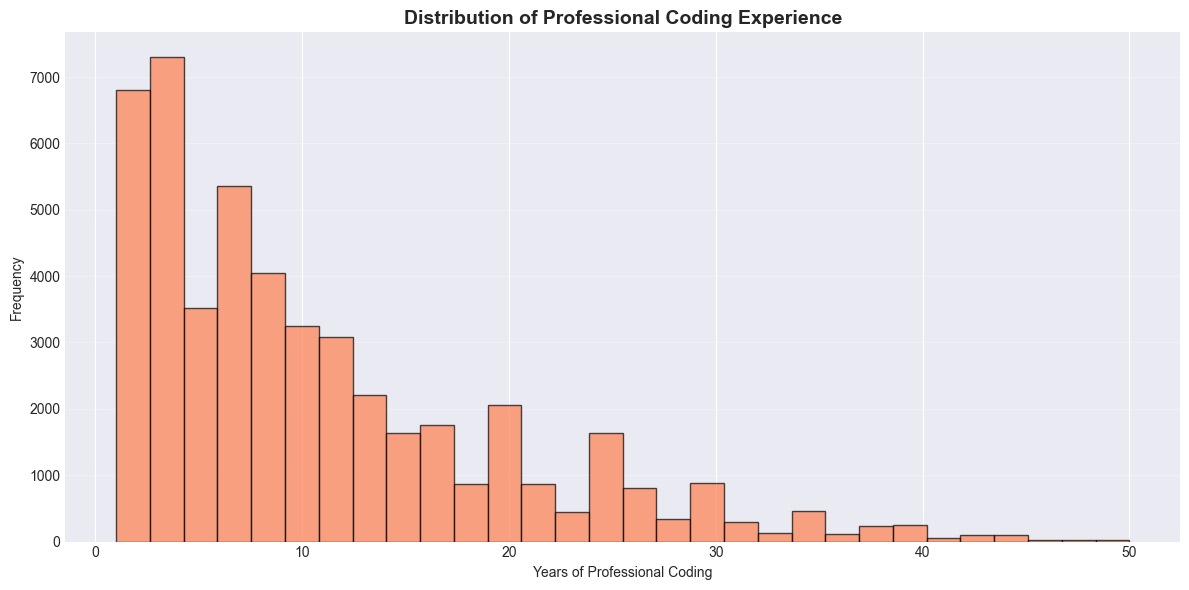

Total records: 48704
Mean experience: 10.74 years
Median experience: 8.00 years


In [39]:
# Query years of experience
QUERY = """
SELECT YearsCodePro 
FROM main 
WHERE YearsCodePro IS NOT NULL
"""
exp_data = pd.read_sql_query(QUERY, conn)

# Convert to numeric
exp_data['YearsCodePro'] = pd.to_numeric(exp_data['YearsCodePro'], errors='coerce')
exp_data = exp_data.dropna()

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(exp_data['YearsCodePro'], bins=30, color='coral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Professional Coding Experience', fontsize=14, fontweight='bold')
plt.xlabel('Years of Professional Coding')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total records: {len(exp_data)}")
print(f"Mean experience: {exp_data['YearsCodePro'].mean():.2f} years")
print(f"Median experience: {exp_data['YearsCodePro'].median():.2f} years")

## Visualizing Relationships in Data

### Histogram 3: Compensation by Age Group

I'll compare compensation distributions across different age groups.

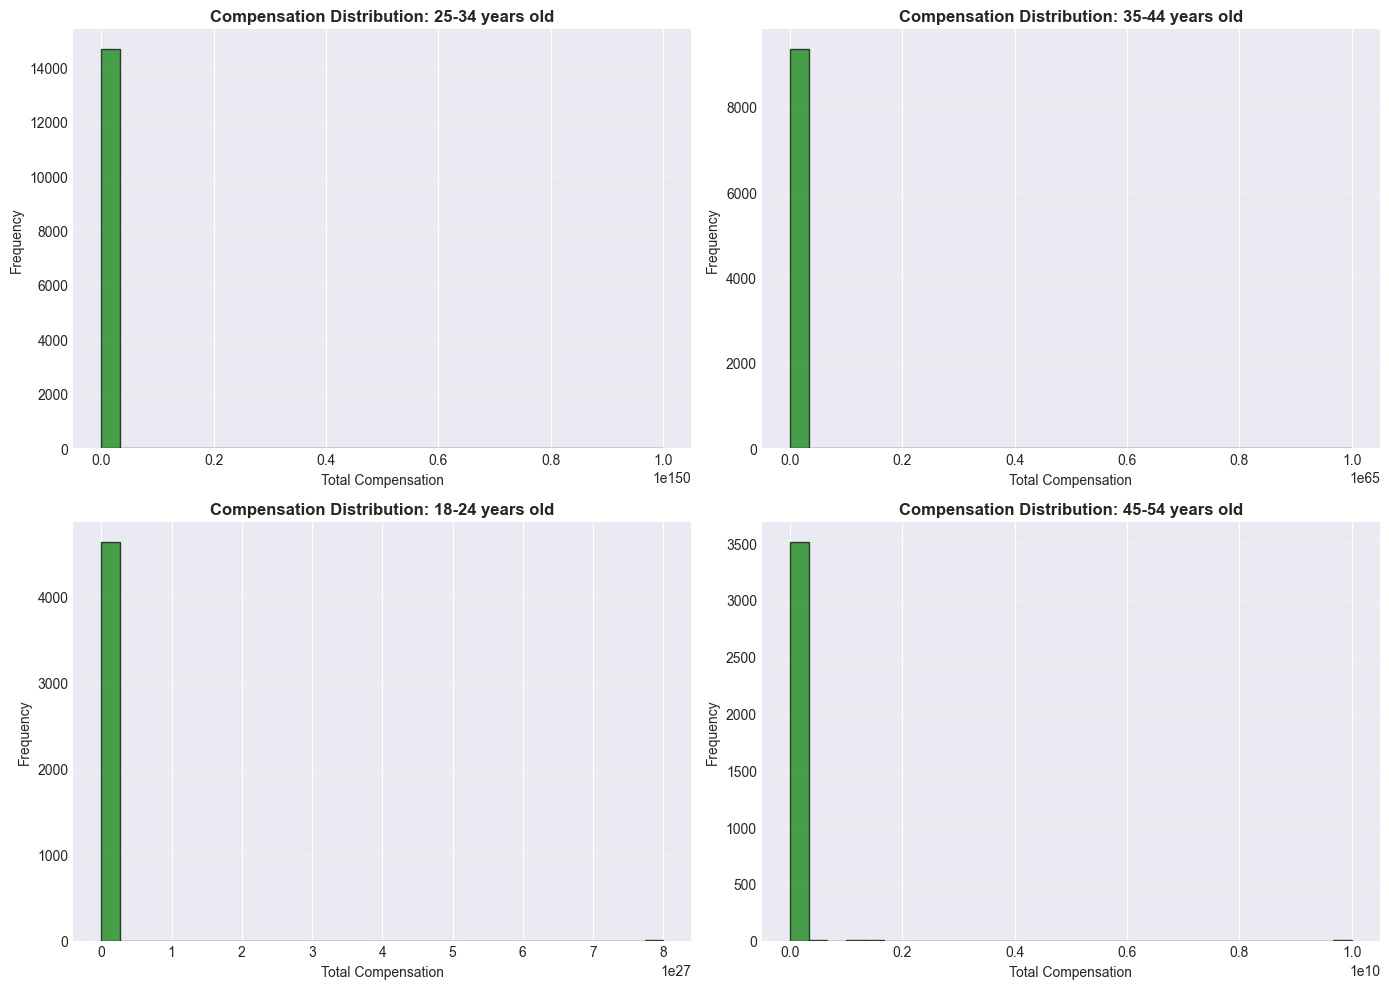

In [40]:
# Query compensation and age
QUERY = """
SELECT Age, CompTotal 
FROM main 
WHERE Age IS NOT NULL 
  AND CompTotal IS NOT NULL
"""
age_comp = pd.read_sql_query(QUERY, conn)

# Get top 4 age groups
top_ages = age_comp['Age'].value_counts().head(4).index

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, age in enumerate(top_ages):
    age_subset = age_comp[age_comp['Age'] == age]['CompTotal']
    axes[idx].hist(age_subset, bins=30, color='green', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Compensation Distribution: {age}', fontweight='bold')
    axes[idx].set_xlabel('Total Compensation')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Histogram 4: Time Searching by Age Group

I'll explore how time spent searching varies across age groups.

In [41]:
# Query time searching by age
QUERY = """
SELECT Age, TimeSearching 
FROM main 
WHERE Age IS NOT NULL 
  AND TimeSearching IS NOT NULL
"""
age_time = pd.read_sql_query(QUERY, conn)

top_3_ages = age_time['Age'].value_counts().head(3).index

# Build a pivot table for grouped bar chart (avoids x-axis misalignment)
time_pivot = (age_time[age_time['Age'].isin(top_3_ages)]
              .groupby(['Age', 'TimeSearching'])
              .size()
              .unstack(fill_value=0))

plt.figure(figsize=(14, 6))
time_pivot.T.plot(kind='bar', ax=plt.gca(), alpha=0.7, edgecolor='black')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Time Searching Distribution by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Time Searching Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Visualizing Composition of Data

### Histogram 5: Most Desired Databases

I'll visualize the top 5 databases developers want to work with.

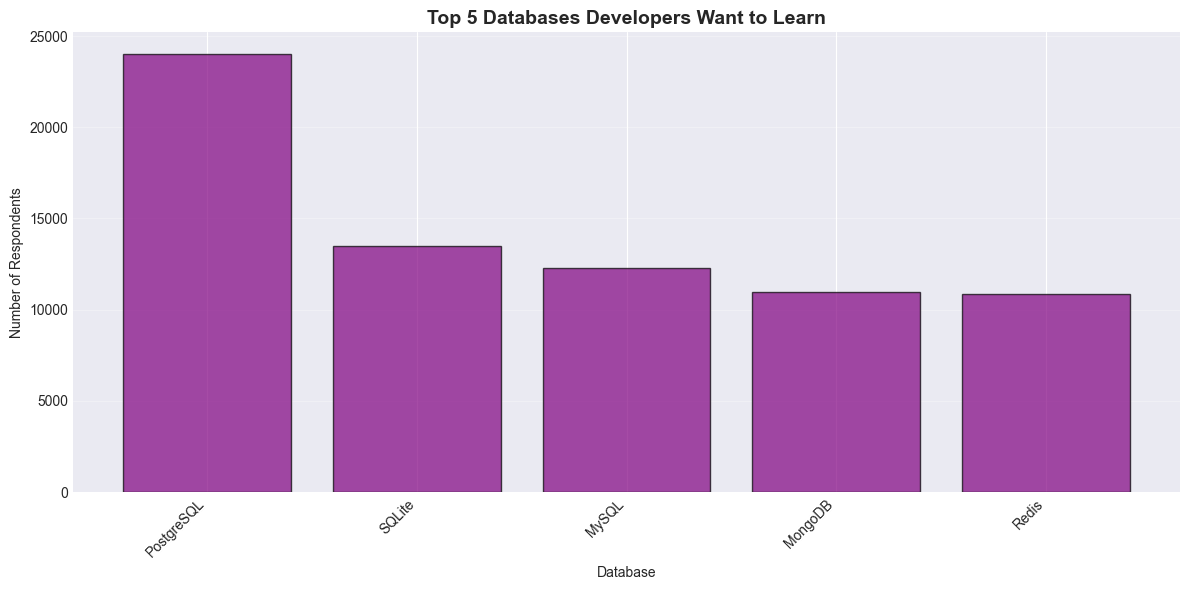

Top 5 Databases:
DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


In [42]:
# Query database preferences
QUERY = """
SELECT DatabaseWantToWorkWith 
FROM main 
WHERE DatabaseWantToWorkWith IS NOT NULL
"""
db_data = pd.read_sql_query(QUERY, conn)

# Split and count
all_databases = db_data['DatabaseWantToWorkWith'].str.split(';').explode()
top_5_db = all_databases.value_counts().head(5)

# Create bar histogram
plt.figure(figsize=(12, 6))
plt.bar(range(len(top_5_db)), top_5_db.values, color='purple', edgecolor='black', alpha=0.7)
plt.xticks(range(len(top_5_db)), top_5_db.index, rotation=45, ha='right')
plt.title('Top 5 Databases Developers Want to Learn', fontsize=14, fontweight='bold')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 Databases:")
print(top_5_db)

### Histogram 6: Remote Work Preferences

I'll visualize the distribution of work arrangement preferences.

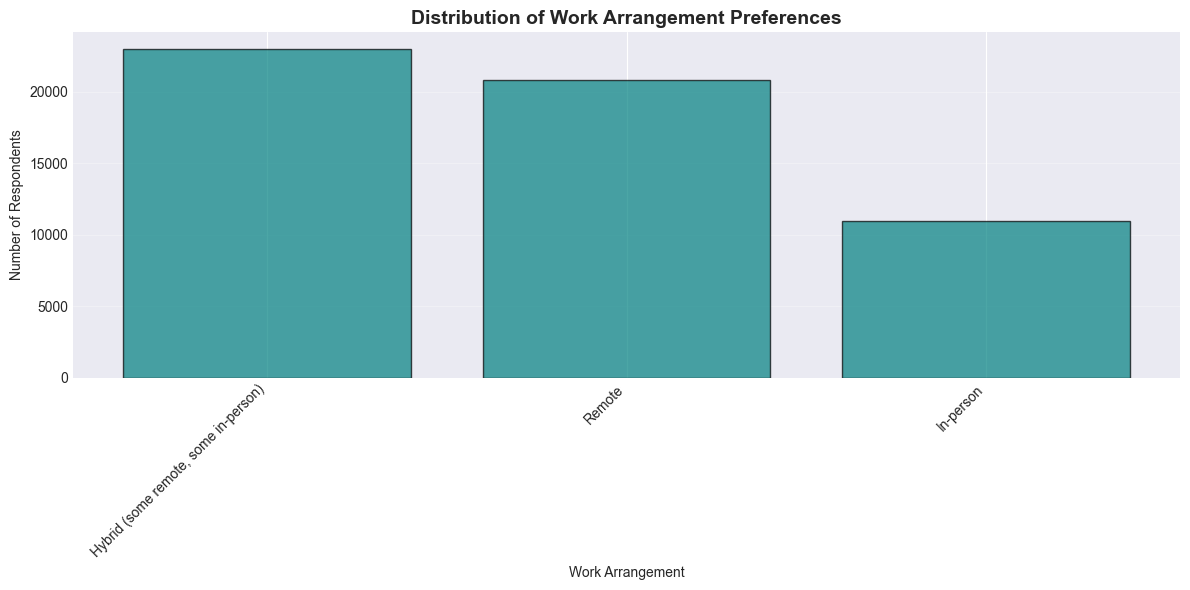

Remote Work Distribution:
                             RemoteWork  count
0  Hybrid (some remote, some in-person)  23015
1                                Remote  20831
2                             In-person  10960


In [43]:
# Query remote work preferences
QUERY = """
SELECT RemoteWork, COUNT(*) as count
FROM main 
WHERE RemoteWork IS NOT NULL
GROUP BY RemoteWork
ORDER BY count DESC
"""
remote_data = pd.read_sql_query(QUERY, conn)

# Create histogram
plt.figure(figsize=(12, 6))
plt.bar(remote_data['RemoteWork'], remote_data['count'], color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribution of Work Arrangement Preferences', fontsize=14, fontweight='bold')
plt.xlabel('Work Arrangement')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Remote Work Distribution:")
print(remote_data)

## Visualizing Comparison of Data

### Histogram 7: Compensation for Age 45-64

I'll analyze compensation distribution for respondents aged 45-64.

In [44]:
# Query compensation for age group 45-64
QUERY = """
SELECT CompTotal 
FROM main 
WHERE Age IN ('45-54 years old', '55-64 years old')
  AND CompTotal IS NOT NULL
"""
comp_mid_career = pd.read_sql_query(QUERY, conn)

# Remove extreme outliers using IQR method for meaningful visualization
Q1 = comp_mid_career['CompTotal'].quantile(0.25)
Q3 = comp_mid_career['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
comp_mid_career = comp_mid_career[(comp_mid_career['CompTotal'] >= Q1 - 1.5 * IQR) &
                                  (comp_mid_career['CompTotal'] <= Q3 + 1.5 * IQR)]

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(comp_mid_career['CompTotal'], bins=40, color='orange', edgecolor='black', alpha=0.7)
plt.title('Compensation Distribution for Age 45-64', fontsize=14, fontweight='bold')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total records: {len(comp_mid_career)}")
print(f"Mean: {comp_mid_career['CompTotal'].mean():,.2f}")
print(f"Median: {comp_mid_career['CompTotal'].median():,.2f}")

### Histogram 8: Job Satisfaction by Experience

I'll explore how job satisfaction varies with coding experience.

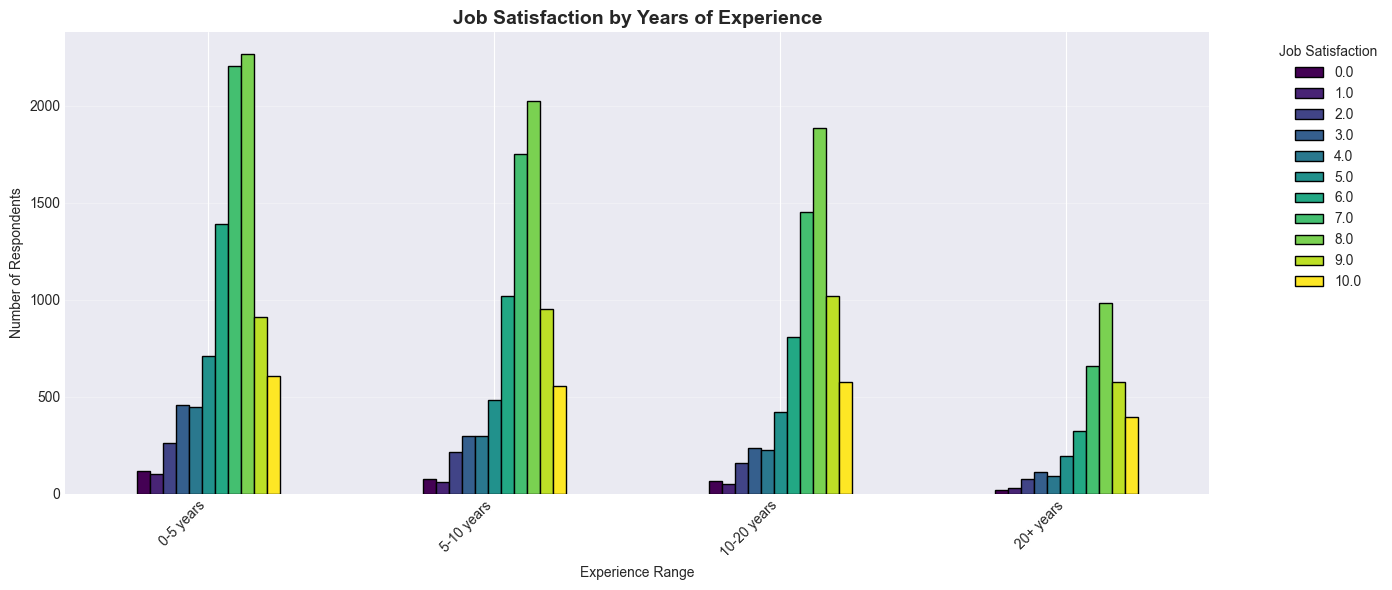

In [45]:
# Query job satisfaction and experience
QUERY = """
SELECT YearsCodePro, JobSat 
FROM main 
WHERE YearsCodePro IS NOT NULL 
  AND JobSat IS NOT NULL
"""
jobsat_exp = pd.read_sql_query(QUERY, conn)

# Convert to numeric
jobsat_exp['YearsCodePro'] = pd.to_numeric(jobsat_exp['YearsCodePro'], errors='coerce')
jobsat_exp = jobsat_exp.dropna()

# Create experience bins
bins = [0, 5, 10, 20, 100]
labels = ['0-5 years', '5-10 years', '10-20 years', '20+ years']
jobsat_exp['ExpRange'] = pd.cut(jobsat_exp['YearsCodePro'], bins=bins, labels=labels)

# Count job satisfaction by experience range
jobsat_counts = jobsat_exp.groupby(['ExpRange', 'JobSat']).size().unstack(fill_value=0)

# Create grouped bar chart
jobsat_counts.plot(kind='bar', figsize=(14, 6), colormap='viridis', edgecolor='black')
plt.title('Job Satisfaction by Years of Experience', fontsize=14, fontweight='bold')
plt.xlabel('Experience Range')
plt.ylabel('Number of Respondents')
plt.legend(title='Job Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Closing the Database Connection

Finally, I'll close the database connection.

In [46]:
# Close the database connection
conn.close()
print("✅ Database connection closed")

✅ Database connection closed


## Summary

In this notebook, I used histograms to visualize various aspects of the developer survey data:

- **Distribution analysis** - Compensation and coding experience patterns
- **Relationship exploration** - How compensation and time searching vary across age groups
- **Composition visualization** - Most desired databases and remote work preferences
- **Comparison analysis** - Mid-career compensation and job satisfaction by experience level

Histograms are powerful tools for understanding data distributions and revealing patterns that might not be obvious from summary statistics alone. These visualizations help identify trends, outliers, and relationships in the developer survey data.